In [1]:
import os
import sqlite3

import pandas as pd

from typing import Optional
from pathlib import Path
from pandas import DataFrame
from sklearn.preprocessing import LabelEncoder
from pycaret.classification import *

# Funtions

In [2]:
def get_path(prev_folders: int = 0) -> str:
    """
    Identifies a specific directory according to the absolute path of the file.
    Args:
        prev_folders (int): An integer indicating the number of previous folders to get. If not given, 0 (current folder) is used by default.

    Returns:
        str: A text string with the identified path.
    """
    # Error handling
    if not isinstance(prev_folders, int) or prev_folders < 0:
        raise ValueError("prev_folders must be a non-negative integer")

    # Use pathlib to handle paths and directories
    path = Path.cwd()
    
    # Go up the specified number of directories
    for _ in range(prev_folders):
        path = path.parent
    
    # Use pathlib's as_posix method to get the string representation of the path
    # This automatically ensures the path ends with a slash
    path_str = path.as_posix() + '/'
    
    return path_str

In [3]:
def read_data_from_database(db_path: str, table_name: str) -> Optional[pd.DataFrame]:
    """
    Read data from a SQLite database table into a pandas DataFrame.

    Parameters:
    db_path (str): The path to the SQLite database.
    table_name (str): The name of the table in the database.

    Returns:
    Optional[pd.DataFrame]: The loaded DataFrame if successful, None otherwise.
    """
    try:
        conn = sqlite3.connect(db_path)
        consulta_sql = f"SELECT * FROM {table_name}"
        df = pd.read_sql_query(consulta_sql, conn)
        return df
    except sqlite3.Error as e:
        print(f"An error occurred while reading data from the database:\n{e}")
        return None  # Return None in case of error
    finally:
        if 'conn' in locals():
            conn.close()

In [4]:
def label_encoder(var_encoder: str, encoder_name: str, dataframe: DataFrame) -> None:
    """
    Encodes a categorical variable in a DataFrame using LabelEncoder.

    Args:
        var_encoder (str): The name of the categorical variable to be encoded.
        encoder_name (str): The name of the column to store the encoded values.
        dataframe (DataFrame): The DataFrame containing the variable to be encoded.

    Returns:
        None
    """
    encoder_name = LabelEncoder()
    var_coded = var_encoder + '_ENC'
    dataframe[var_coded] = encoder_name.fit_transform(dataframe[var_encoder])

# Environment settings

In [5]:
pd.options.display.max_columns = None  # Remove "dots" from display when printing dataframes

In [6]:
PATH = get_path(2)
DATABASE_FOLDER = PATH + 'data/preprocessing/BANCO_BOGOTA.db'

# Read data

In [7]:
df_train = read_data_from_database(DATABASE_FOLDER, 'prep_train_data')
df_test = read_data_from_database(DATABASE_FOLDER, 'prep_test_data')

In [8]:
df_train.head()

,ID,Edad,Tipo_Trabajo,Estado_Civil,Educacion,mora,Vivienda,Consumo,Contacto,Mes,Dia,Campana,Dias_Ultima_Camp,No_Contactos,Resultado_Anterior,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,1,57,servicios,casado,bachillerato,0.0,0.0,0.0,telefono fijo,may,lun,1,-1,0,sin contacto,1.1,93994.0,-36.4,4857.0,5191,0
1,2,37,servicios,casado,bachillerato,0.0,1.0,0.0,telefono fijo,may,lun,1,-1,0,sin contacto,1.1,93994.0,-36.4,4857.0,5191,0
2,3,40,administrador negocio,casado,primaria,0.0,0.0,0.0,telefono fijo,may,lun,1,-1,0,sin contacto,1.1,93994.0,-36.4,4857.0,5191,0
3,4,56,servicios,casado,bachillerato,0.0,0.0,1.0,telefono fijo,may,lun,1,-1,0,sin contacto,1.1,93994.0,-36.4,4857.0,5191,0
4,7,25,servicios,soltero,bachillerato,0.0,1.0,0.0,telefono fijo,may,lun,1,-1,0,sin contacto,1.1,93994.0,-36.4,4857.0,5191,0


# Label encoder

In [9]:
labels_to_encoders_name = {
    'Tipo_Trabajo':'Tipo_Trabajo_ENC',
    'Estado_Civil':'Estado_Civil_ENC',
    'Educacion':'Educacion_ENC',    
    'Contacto':'Contacto_ENC',
    'Mes':'Mes_ENC',
    'Dia':'Dia_ENC',
    'Resultado_Anterior':'Resultado_Anterior_ENC'
    }

for var_encoder, encoder_name in labels_to_encoders_name.items():
    label_encoder(var_encoder, encoder_name, df_train)
    label_encoder(var_encoder, encoder_name, df_test)

In [10]:
df_train[[
    'Tipo_Trabajo', 'Tipo_Trabajo_ENC', 'Estado_Civil', 'Estado_Civil_ENC',
    'Educacion', 'Educacion_ENC', 'Contacto', 'Contacto_ENC', 'Mes', 'Mes_ENC',
    'Dia', 'Dia_ENC','Resultado_Anterior', 'Resultado_Anterior_ENC'
    ]].sample(n=10).head(10)

,Tipo_Trabajo,Tipo_Trabajo_ENC,Estado_Civil,Estado_Civil_ENC,Educacion,Educacion_ENC,Contacto,Contacto_ENC,Mes,Mes_ENC,Dia,Dia_ENC,Resultado_Anterior,Resultado_Anterior_ENC
14846,tecnico,8,casado,0,bachillerato,0,celular,0,nov,7,jue,0,sin contacto,2
1258,servicios,7,casado,0,bachillerato,0,telefono fijo,1,may,6,mar,2,sin contacto,2
1689,empleado,3,divorciado,1,pregrado,5,telefono fijo,1,may,6,mié,3,sin contacto,2
21618,pensionado,6,casado,0,bachillerato,0,celular,0,oct,8,mié,3,satisfactorio,1
10261,administrador negocio,0,casado,0,pregrado,5,celular,0,jul,3,mié,3,sin contacto,2
22332,estudiante,5,soltero,2,bachillerato,0,celular,0,jun,4,lun,1,fallido,0
22037,tecnico,8,casado,0,pregrado,5,celular,0,mar,5,lun,1,satisfactorio,1
12426,administrador negocio,0,divorciado,1,estudiante universitario,2,celular,0,ago,1,mié,3,sin contacto,2
3873,administrador negocio,0,divorciado,1,pregrado,5,telefono fijo,1,may,6,mié,3,sin contacto,2
17088,administrador negocio,0,soltero,2,bachillerato,0,celular,0,abr,0,jue,0,sin contacto,2


# Auto Machine Learning

In [11]:
df_new = df_train[[
    'Tipo_Trabajo_ENC', 'Estado_Civil_ENC',
    'mora', 'Vivienda', 'Consumo', 'Contacto_ENC',
    'Dias_Ultima_Camp', 'No_Contactos',
    'emp_var_rate', 'cons_price_idx', 'cons_conf_idx',
    'euribor3m', 'y'
    ]].copy()

df_new.head()

,Tipo_Trabajo_ENC,Estado_Civil_ENC,mora,Vivienda,Consumo,Contacto_ENC,Dias_Ultima_Camp,No_Contactos,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,y
0,7,0,0.0,0.0,0.0,1,-1,0,1.1,93994.0,-36.4,4857.0,0
1,7,0,0.0,1.0,0.0,1,-1,0,1.1,93994.0,-36.4,4857.0,0
2,0,0,0.0,0.0,0.0,1,-1,0,1.1,93994.0,-36.4,4857.0,0
3,7,0,0.0,0.0,1.0,1,-1,0,1.1,93994.0,-36.4,4857.0,0
4,7,2,0.0,1.0,0.0,1,-1,0,1.1,93994.0,-36.4,4857.0,0


In [12]:
data = df_new.sample(frac=0.8, random_state=0)
data_unseen = df_train.drop(data.index)

In [13]:
data.reset_index(inplace=True, drop=True)
data_unseen.reset_index(inplace=True, drop=True)
print(f'Datos para modelar: {data.shape}; y datos para predecir: {data_unseen.shape}')

Datos para modelar: (18479, 13); y datos para predecir: (4620, 28)


In [14]:
model_setup = setup(data=data, target='y')

,Description,Value
0,Session id,7167
1,Target,y
2,Target type,Binary
3,Original data shape,"(18479, 13)"
4,Transformed data shape,"(18479, 13)"
5,Transformed train set shape,"(12935, 13)"
6,Transformed test set shape,"(5544, 13)"
7,Numeric features,12
8,Preprocess,True
9,Imputation type,simple


In [15]:
models()  # Modelos suportados

,Name,Reference,Turbo
ID,,,
lr,Logistic Regression,sklearn.linear_model._logistic.LogisticRegression,True
knn,K Neighbors Classifier,sklearn.neighbors._classification.KNeighborsCl...,True
nb,Naive Bayes,sklearn.naive_bayes.GaussianNB,True
dt,Decision Tree Classifier,sklearn.tree._classes.DecisionTreeClassifier,True
svm,SVM - Linear Kernel,sklearn.linear_model._stochastic_gradient.SGDC...,True
rbfsvm,SVM - Radial Kernel,sklearn.svm._classes.SVC,False
gpc,Gaussian Process Classifier,sklearn.gaussian_process._gpc.GaussianProcessC...,False
mlp,MLP Classifier,sklearn.neural_network._multilayer_perceptron....,False
ridge,Ridge Classifier,sklearn.linear_model._ridge.RidgeClassifier,True


In [16]:
best_models = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ada,Ada Boost Classifier,0.8986,0.7796,0.2023,0.6824,0.3113,0.2736,0.3339,0.0480
gbc,Gradient Boosting Classifier,0.8977,0.7823,0.2160,0.6499,0.3236,0.2831,0.3343,0.1050
lightgbm,Light Gradient Boosting Machine,0.8963,0.7743,0.2514,0.6041,0.3540,0.3082,0.3438,0.1030
lr,Logistic Regression,0.8956,0.7631,0.1546,0.6766,0.2514,0.2183,0.2893,0.4800
catboost,CatBoost Classifier,0.8946,0.7729,0.2466,0.5853,0.3460,0.2991,0.3328,3.3100
ridge,Ridge Classifier,0.8940,0.7560,0.1328,0.6709,0.2215,0.1910,0.2660,0.0080
xgboost,Extreme Gradient Boosting,0.8919,0.7587,0.2657,0.5517,0.3579,0.3067,0.3316,0.0350
knn,K Neighbors Classifier,0.8908,0.7216,0.2827,0.5357,0.3693,0.3160,0.3357,0.3060
lda,Linear Discriminant Analysis,0.8876,0.7560,0.2670,0.5108,0.3504,0.2954,0.3143,0.0090
svm,SVM - Linear Kernel,0.8865,0.7211,0.0000,0.0000,0.0000,0.0000,0.0000,0.0260


In [17]:
ada = create_model('ada')
print(ada)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8957,0.7957,0.2041,0.6250,0.3077,0.2667,0.3163
1,0.8926,0.7723,0.1701,0.5952,0.2646,0.2254,0.2780
2,0.9019,0.8011,0.2381,0.7000,0.3553,0.3159,0.3705
3,0.9049,0.7745,0.2517,0.7400,0.3756,0.3374,0.3957
4,0.8995,0.7937,0.1973,0.7073,0.3085,0.2725,0.3384
5,0.8995,0.7759,0.1918,0.7000,0.3011,0.2654,0.3314
6,0.9049,0.7982,0.2192,0.7805,0.3422,0.3080,0.3817
7,0.8886,0.7376,0.1837,0.5294,0.2727,0.2275,0.2654
8,0.9010,0.7917,0.1837,0.7714,0.2967,0.2645,0.3456


AdaBoostClassifier(algorithm='SAMME.R', estimator=None, learning_rate=1.0,
                   n_estimators=50, random_state=7167)


In [18]:
tuned_ada = tune_model(ada)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8957,0.7907,0.1633,0.6667,0.2623,0.2278,0.2948
1,0.8980,0.7693,0.1429,0.7778,0.2414,0.2137,0.3055
2,0.9019,0.7953,0.1905,0.7778,0.3060,0.2735,0.3541
3,0.9026,0.7840,0.1973,0.7838,0.3152,0.2824,0.3623
4,0.8972,0.7624,0.1633,0.7059,0.2652,0.2324,0.3066
5,0.9026,0.7629,0.1712,0.8333,0.2841,0.2554,0.3508
6,0.8995,0.7824,0.1507,0.7857,0.2529,0.2247,0.3163
7,0.8940,0.7312,0.1565,0.6389,0.2514,0.2163,0.2800
8,0.8995,0.7851,0.1633,0.7742,0.2697,0.2395,0.3261


Fitting 10 folds for each of 10 candidates, totalling 100 fits


# Analyze Model

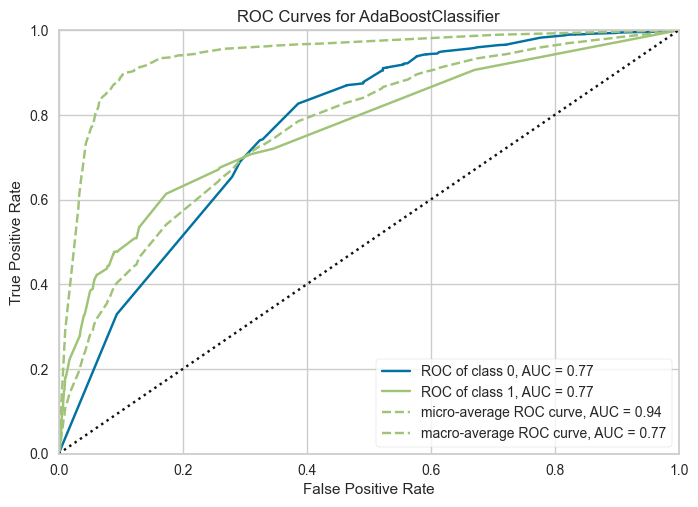

In [19]:
plot_model(estimator = tuned_ada, plot = 'auc')

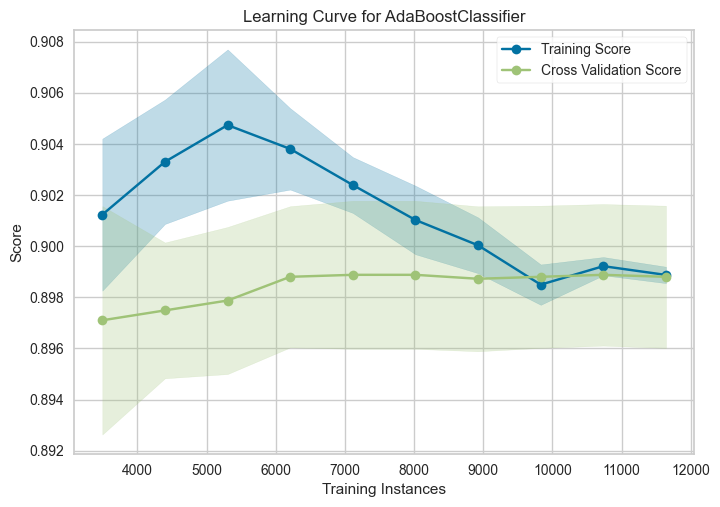

In [20]:
plot_model(estimator = tuned_ada, plot = 'learning')

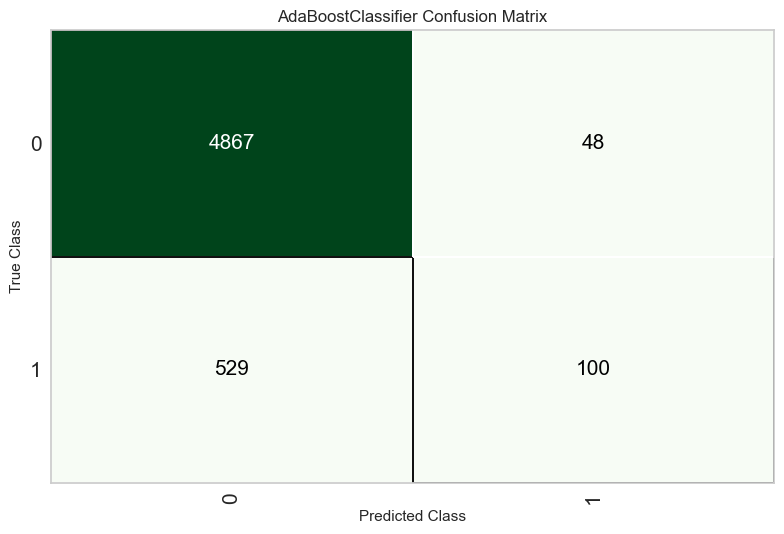

In [21]:
plot_model(estimator = tuned_ada, plot = 'confusion_matrix')

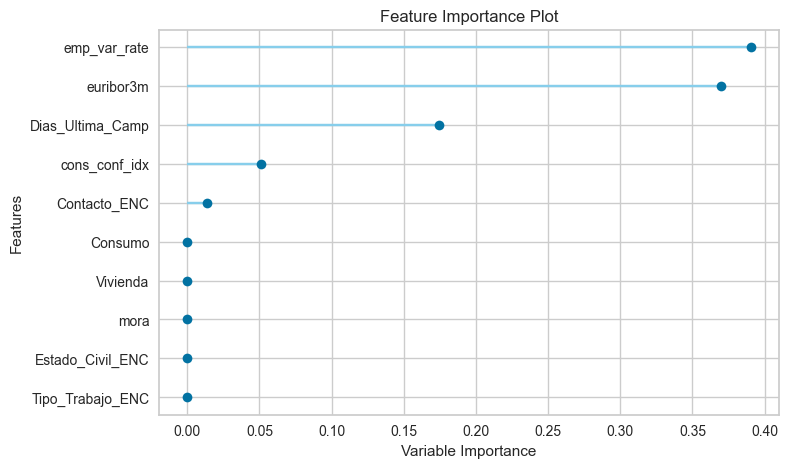

In [22]:
plot_model(tuned_ada, plot='feature')

In [23]:
unseen_predictions = predict_model(tuned_ada, data=data_unseen)
unseen_predictions[['y', 'prediction_label', 'prediction_score']].sample(n=25).head(25)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ada Boost Classifier,0.9019,0.7842,0.1582,0.6724,0.2562,0.2246,0.2940


,y,prediction_label,prediction_score
3491,0,0,0.7864
4568,1,1,0.5423
1864,0,0,0.8635
3525,0,0,0.7864
195,0,0,0.8700
2685,0,0,0.8635
62,0,0,0.8700
2727,0,0,0.8635
4593,1,0,0.7287
97,0,0,0.8700


In [24]:
final_ada = finalize_model(tuned_ada)
print(final_ada)

Pipeline(memory=Memory(location=None),
         steps=[('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['Tipo_Trabajo_ENC',
                                             'Estado_Civil_ENC', 'mora',
                                             'Vivienda', 'Consumo',
                                             'Contacto_ENC', 'Dias_Ultima_Camp',
                                             'No_Contactos', 'emp_var_rate',
                                             'cons_price_idx', 'cons_conf_idx',
                                             'euribor3m'],
                                    transformer=SimpleImputer(add_indicator=False,
                                                              copy=True,
                                                              fill_value=...
                ('categorical_imputer',
                 TransformerWrapper(exclude=None, include=[],
                                   

# Save model

In [25]:
save_model(final_ada, PATH + 'data/salida/ADA_model_08-05-2024')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['Tipo_Trabajo_ENC',
                                              'Estado_Civil_ENC', 'mora',
                                              'Vivienda', 'Consumo',
                                              'Contacto_ENC', 'Dias_Ultima_Camp',
                                              'No_Contactos', 'emp_var_rate',
                                              'cons_price_idx', 'cons_conf_idx',
                                              'euribor3m'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=...
                 ('categorical_imputer',
                  TransformerWrapper(exclude=None, include=[],
                    

# Deploy

In [26]:
ada_model = load_model(PATH + 'data/salida/ADA_model_08-05-2024')

Transformation Pipeline and Model Successfully Loaded


In [27]:
df_implement = predict_model(ada_model, data=df_test)
df_implement = df_implement.rename({
    'prediction_label':'y'
    }, axis=1)

In [28]:
df_implement.head()

,ID,Edad,Tipo_Trabajo,Estado_Civil,Educacion,mora,Vivienda,Consumo,Contacto,Mes,...,nr_employed,Tipo_Trabajo_ENC,Estado_Civil_ENC,Educacion_ENC,Contacto_ENC,Mes_ENC,Dia_ENC,Resultado_Anterior_ENC,y,prediction_score
0,5,41,empleado,casado,pregrado,0.0,0.0,0.0,telefono fijo,may,...,5191,3,0,5,1,6,1,2,0,0.8711
1,6,24,tecnico,soltero,estudiante universitario,0.0,1.0,0.0,telefono fijo,may,...,5191,8,2,2,1,6,1,2,0,0.8711
2,11,57,ama de casa,divorciado,preescolar,0.0,1.0,0.0,telefono fijo,may,...,5191,1,1,4,1,6,1,2,0,0.8711
3,13,54,pensionado,casado,bachillerato incompleto,0.0,1.0,1.0,telefono fijo,may,...,5191,6,0,1,1,6,1,2,0,0.8711
4,16,39,vive de los arriendos,soltero,bachillerato incompleto,0.0,0.0,0.0,telefono fijo,may,...,5191,10,2,1,1,6,1,2,0,0.8711


In [29]:
mean = df_implement['prediction_score'].mean().round(3)
std = df_implement['prediction_score'].std().round(3)

print(f'Promedio de predicción del modelo: {mean}.\nDesviación estandar de la predicción del modelo: {std}')

Promedio de predicción del modelo: 0.814.
Desviación estandar de la predicción del modelo: 0.084


# Save data

In [32]:
# Load to DataBase
try:
    # Create a connection to the SQLite database
    conn = sqlite3.connect(os.path.join(PATH, 'data', 'preprocessing', 'BANCO_BOGOTA.db'))

    df_implement.to_sql(
    'Result_TechnicalTest_DS_AMT', conn, index=False, if_exists='replace'    
    )
    # Commit changes
    conn.commit()
    print('Data loaded successfully to the database.')
except Exception as e:
    print(f'An error occurred while loading data to the database: {str(e)}')
    if conn is not None:
        conn.rollback()
finally:
    # Close connection
    if conn is not None:
        conn.close()
        print('Database connection closed.')

Data loaded successfully to the database.
Database connection closed.


In [33]:
del df_train, df_test, df_new, df_implement  # Delete variables to free memory